In [ ]:
from huggingface_hub import login
# login("token")
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import statistics as stats
import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, util


In [ ]:
ds = load_dataset("minnesotanlp/scholawrite")
all_sorted_df = pd.DataFrame(ds["all_sorted"])
all_sorted_df['project'].value_counts()
all_sorted_df["datetime"] = pd.to_datetime(all_sorted_df["timestamp"], unit="ms", utc=True)
all_sorted_df["datetime"] = all_sorted_df["datetime"].dt.strftime("%Y-%m-%d %H:%M:%S.%f%z")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/203M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/50.5M [00:00<?, ?B/s]

data/test_small-00000-of-00001.parquet:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

...

data/all_sorted-00001-of-00002.parquet:   0%|          | 0.00/32.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49212 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12292 [00:00<?, ? examples/s]

Generating test_small split:   0%|          | 0/3238 [00:00<?, ? examples/s]

Generating all_sorted split:   0%|          | 0/61504 [00:00<?, ? examples/s]

# threshold for session/ intention session

In [ ]:
time_diff = []
for i in range(1, 6):
  data = all_sorted_df[all_sorted_df['project'] == i].sort_values(by=["author","timestamp"])
  unique_author = data[["author"]].drop_duplicates().values.tolist()
  for author in unique_author:
    records = data[data['author'] == author[0]]
    n = len(records)
    time_diff += [subtract(records.iloc[j]['datetime'], records.iloc[j-1]['datetime']) for j in range(1, n)]


In [ ]:
arr = np.array(time_diff)

# Compute stats
stats = {
    "min": arr.min(),
    "max": arr.max(),
    "mean": arr.mean(),
    "median": np.median(arr),
    "std": arr.std()
}

print(stats)


{'min': np.float64(0.0), 'max': np.float64(50185.494150000006), 'mean': np.float64(12.341054888982848), 'median': np.float64(0.020166666666666666), 'std': np.float64(441.77441637851786)}


In [ ]:
time_dict = {
    "<0.5": 0,
    "<1": 0,
    "<5": 0,
    "<10": 0,
    "<20": 0,
    "<30": 0,
    "<60": 0,
    "<120": 0,
    "less than 1 day": 0,
    "1 day": 0,
    "5 day": 0,
    "10 day": 0,
    "more than 10 day": 0
}
for value in time_diff:
  if value < 0.5:
    time_dict["<0.5"] += 1
  elif value < 1:
    time_dict["<1"] += 1
  elif value < 5:
    time_dict["<5"] += 1
  elif value < 10:
    time_dict["<10"] += 1
  elif value < 20:
    time_dict['<20'] += 1
  elif value < 30:
    time_dict['<30'] += 1
  elif value < 60:
    time_dict['<60'] += 1
  elif value < 120:
    time_dict['<120'] += 1
  elif value < 60*24:
    time_dict["less than 1 day"] += 1
  elif value < 60*24*2:
    time_dict["1 day"] += 1
  elif value < 60*24*5:
    time_dict["5 day"] += 1
  elif value < 60*24*10:
    time_dict["10 day"] += 1
  else:
    time_dict["more than 10 day"] += 1

print(time_dict)

{'<0.5': 57872, '<1': 1373, '<5': 1461, '<10': 226, '<20': 159, '<30': 65, '<60': 77, '<120': 46, 'less than 1 day': 131, '1 day': 25, '5 day': 25, '10 day': 21, 'more than 10 day': 11}


In [ ]:
import numpy as np

labels = ['<0.5', '<1', '<5', '<10', '<20', '<30', '<60', '<120',
          '<1 day', '1 day', '5 day', '10 day', '>10 day']

counts = np.array([57872, 1373, 1461, 226, 159, 65, 77, 46, 131, 25, 25, 21, 11])

# percent drop from one bucket to next
drops = 100 * (1 - counts[1:] / counts[:-1])

for i in range(len(drops)):
    print(f"{labels[i]} → {labels[i+1]}: {drops[i]:.2f}% drop")


<0.5 → <1: 97.63% drop
<1 → <5: -6.41% drop
<5 → <10: 84.53% drop
<10 → <20: 29.65% drop
<20 → <30: 59.12% drop
<30 → <60: -18.46% drop
<60 → <120: 40.26% drop
<120 → <1 day: -184.78% drop
<1 day → 1 day: 80.92% drop
1 day → 5 day: 0.00% drop
5 day → 10 day: 16.00% drop
10 day → >10 day: 47.62% drop


In [ ]:
!pip install kneed


In [ ]:
from kneed import KneeLocator
short_midpoints = [0.25, 0.75, 3, 7.5, 15, 25, 45]
short_counts = [57872, 1373, 1461, 226, 159, 65, 77]

kl = KneeLocator(
    short_midpoints, short_counts,
    curve='convex',
    direction='decreasing'
)

print("Elbow at (minutes):", kl.knee)


Elbow at (minutes): 0.75


# intention session

In [ ]:
t_val = 10
all_intention_session_save = dict()
model = SentenceTransformer("all-MiniLM-L6-v2")
for i in [1,2,4,5]:
  print(i)
  project_df = all_sorted_df[all_sorted_df['project'] == i].sort_values(by="timestamp")
  records = project_df.to_dict(orient="records")
  n = len(records)

  store = {"duration": [], "start_time": [], "end_time": []}
  intent_session_save = []
  start = records[0]['datetime']
  end = records[0]['datetime']

  before_text = records[0]["before text"]
  after_text = records[0]["after text"]

  label = records[0]['label']
  count = 0

  for j in range(1, n):
    if subtract(records[j]['datetime'], records[j-1]['datetime']) > t_val:
      if subtract(end, start) > 0.01:
        store["duration"].append(subtract(end, start))
        store["start_time"].append(start.split(".")[0])
        store["end_time"].append(end.split(".")[0])
        record = {
            "duration": subtract(end, start),
            "start_time": start.split(".")[0],
            "end_time": end.split(".")[0],
            "index": count,
            "before_text": before_text,
            "after_text": after_text,
            "label": label,
        }
        count += 1
        intent_session_save.append(record)
      start = records[j]['datetime']
      end = records[j]['datetime']

      before_text = records[j]["before text"]
      after_text = records[j]["after text"]

      label = records[j]['label']
    elif label != records[j]['label']:
      if subtract(end, start) > 0.01:
        store["duration"].append(subtract(end, start))
        store["start_time"].append(start.split(".")[0])
        store["end_time"].append(end.split(".")[0])
        record = {
            "duration": subtract(end, start),
            "start_time": start.split(".")[0],
            "end_time": end.split(".")[0],
            "index": count,
            "before_text": before_text,
            "after_text": after_text,
            "label": label,
        }
        count += 1
        intent_session_save.append(record)
      start = records[j]['datetime']
      end = records[j]['datetime']

      before_text = records[j]["before text"]
      after_text = records[j]["after text"]

      label = records[j]['label']
    else:
      emb1 = model.encode(after_text, convert_to_tensor=True)
      emb2 = model.encode(records[j]['before text'], convert_to_tensor=True)
      cos_sim = util.cos_sim(emb1, emb2)
      if cos_sim.item() < 0.5:
        record = {
            "duration": subtract(end, start),
            "start_time": start.split(".")[0],
            "end_time": end.split(".")[0],
            "index": count,
            "before_text": before_text,
            "after_text": after_text,
            "label": label,
        }
        count += 1
        intent_session_save.append(record)
        start = records[j]['datetime']
        end = records[j]['datetime']

        before_text = records[j]["before text"]
        after_text = records[j]["after text"]
        label = records[j]['label']

      else:
        end = records[j]['datetime']
        after_text = records[j]["after text"]

  # all_store[i] = store
  all_intention_session_save[i] = intent_session_save

# stats = {}
# for key, val_dict in all_store.items():
#     arr = np.array(val_dict['duration'])
#     stats[str(key)] = {
#         "mean": np.mean(arr),
#         "variance": np.var(arr, ddof=1) if len(arr) > 1 else 0,
#         "sd": np.std(arr, ddof=1) if len(arr) > 1 else 0,
#         "median": np.median(arr),
#         "max": np.max(arr),
#         "min": np.min(arr),
#         "count": len(arr),
#     }

# df_session = pd.DataFrame.from_dict(stats, orient="index").sort_values(by="variance", ascending=False)
# df_session

1
2
4
5


In [ ]:
for i in [1,2,4,5]:
  df_save = pd.DataFrame(all_intention_session_save[i])
  df_save.to_json(f"intention_session/project_{i}_intent_session.jsonl", orient="records", lines=True)

In [ ]:

store = {"x=0": 0, "0<x<1": 0, "1<x<5": 0, "x>5": 0}
for rec in intent_session_save:
    if rec["duration"] == 0.0:
        store["x=0"] += 1
    elif rec["duration"] < 1:
        store["0<x<1"] += 1
    elif rec['duration'] < 5:
        store["1<x<5"] += 1
    else:
        store["x>5"] += 1

print(store)

NameError: name 'intent_session_save' is not defined

# Session level

In [ ]:
t_val = 10
all_store = dict()
all_session_save = dict()
model = SentenceTransformer("all-MiniLM-L6-v2")
for i in range(1, 6):
  print(i)
  diff_list = []
  project_df = all_sorted_df[all_sorted_df['project'] == i].sort_values(by="timestamp")
  records = project_df.to_dict(orient="records")
  n = len(records)
  store = {"duration": [], "start_time": [], "end_time": []}
  session_save = []
  start = records[0]['datetime']
  before_text = records[0]["before text"]
  after_text = records[0]["after text"]
  end = records[0]['datetime']
  count = 0

  label_list = []
  label_list.append(records[0]['label'])
  for j in range(1, n):
    if subtract(records[j]['datetime'], records[j-1]['datetime']) > t_val:
      if subtract(end, start) > 1.0:
        store["duration"].append(subtract(end, start))
        store["start_time"].append(start.split(".")[0])
        store["end_time"].append(end.split(".")[0])
        record = {
            "duration": subtract(end, start),
            "start_time": start.split(".")[0],
            "end_time": end.split(".")[0],
            "index": count,
            "before_text": before_text,
            "after_text": after_text,
            "label_list": label_list,
        }
        count += 1
        session_save.append(record)
      start = records[j]['datetime']
      end = records[j]['datetime']
      before_text = records[j]["before text"]
      after_text = records[j]["after text"]
      label_list = []
    else:
      ## if they work on different part
      emb1 = model.encode(after_text, convert_to_tensor=True)
      emb2 = model.encode(records[j]['before text'], convert_to_tensor=True)
      cos_sim = util.cos_sim(emb1, emb2)
      if cos_sim.item() < 0.5:
        store["duration"].append(subtract(end, start))
        store["start_time"].append(start.split(".")[0])
        store["end_time"].append(end.split(".")[0])
        record = {
            "duration": subtract(end, start),
            "start_time": start.split(".")[0],
            "end_time": end.split(".")[0],
            "index": count,
            "before_text": before_text,
            "after_text": after_text,
            "label_list": label_list,
        }
        count += 1
        start = records[j]['datetime']
        end = records[j]['datetime']
        session_save.append(record)
        before_text = records[j]["before text"]
        after_text = records[j]["after text"]
        label_list = []

      else:
        end = records[j]['datetime']
        after_text = records[j]["after text"]
        label_list.append(records[j]['label'])

  # all_store[i] = store
  # all_session_save[i] = session_save
  df_save = pd.DataFrame(session_save)
  df_save.to_json(f"project_{i}_session.jsonl", orient="records", lines=True)


1
2
3
4
5


In [ ]:
stats = {}
for key, val_dict in all_store.items():
    arr = np.array(val_dict['duration'])
    stats[str(key)] = {
        "mean": np.mean(arr),
        "variance": np.var(arr, ddof=1) if len(arr) > 1 else 0,
        "sd": np.std(arr, ddof=1) if len(arr) > 1 else 0,
        "median": np.median(arr),
        "max": np.max(arr),
        "min": np.min(arr),
        "count": len(arr),
    }

df_session = pd.DataFrame.from_dict(stats, orient="index").sort_values(by="variance", ascending=False)
df_session

,mean,variance,sd,median,max,min,count
4,5.586587,115.268288,10.736307,1.123817,88.339250,0.0,225
3,6.568536,70.049768,8.369574,2.749567,32.974883,0.0,85
1,3.282647,29.207387,5.404386,1.223067,35.703567,0.0,362
2,2.540774,23.889974,4.887737,0.542000,34.995400,0.0,217
5,1.242227,18.452253,4.295609,0.008858,62.854350,0.0,2102


In [ ]:
emb1 = model.encode(all_session_save[2][4]['before_text'], convert_to_tensor=True)
emb2 = model.encode(all_session_save[2][4]['after_text'], convert_to_tensor=True)

# Compute cosine similarity
cos_sim = util.cos_sim(emb1, emb2)
cos_sim.item()


0.393268346786499

In [ ]:
for i in [1,2, 3,4,5]:
  df_save = pd.DataFrame(all_session_save[i])
  df_save.to_json(f"session/project_{i}_session.jsonl", orient="records", lines=True)

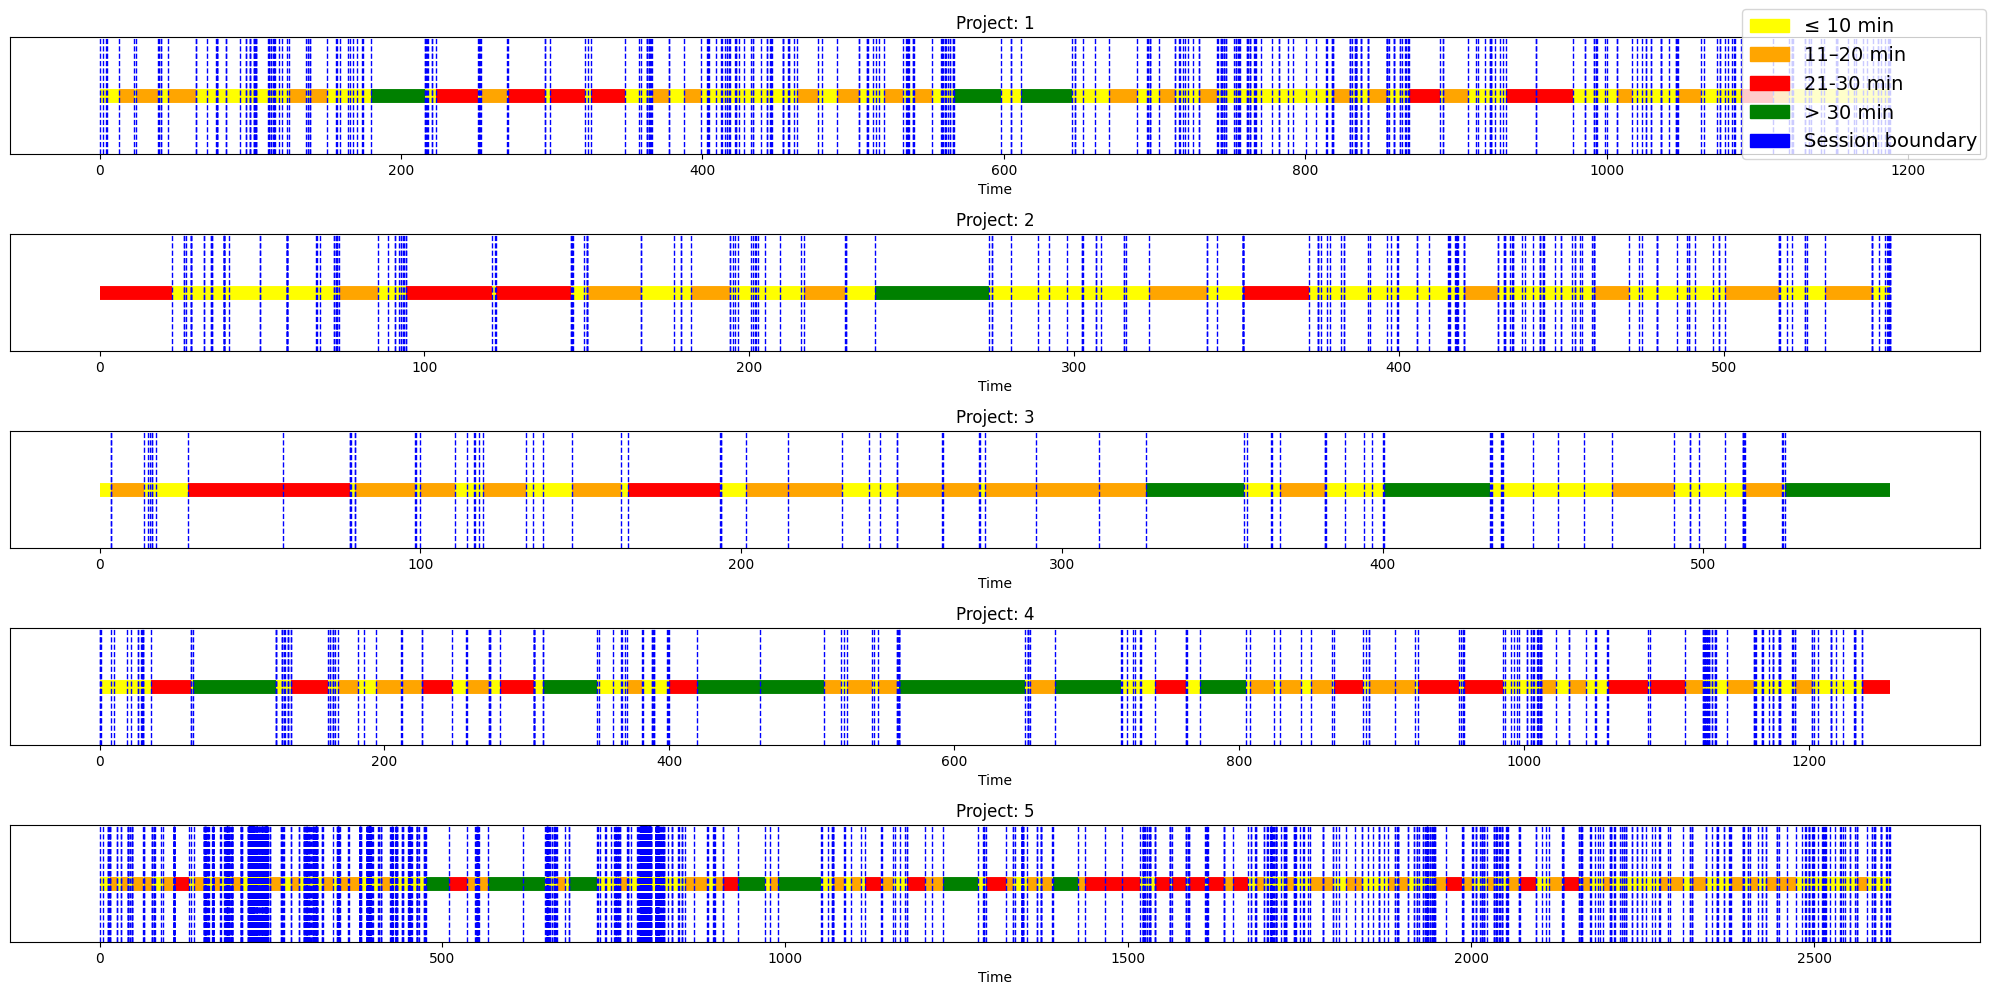

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# Example dict structure: {key: {"duration": [...]}, ...}
data = {key: val_dict['duration'] for key, val_dict in all_store.items()}

fig, axes = plt.subplots(5, 1, figsize=(20, 10), sharex=False, sharey=True)

for ax, (key, durations) in zip(axes, data.items()):
    # Compute start and end times
    starts = np.cumsum([0] + durations[:-1])
    ends = starts + durations

    # Colors by thresholds
    colors = [
        "green" if d > 30 else "red" if d > 20 else "orange" if d > 10 else "yellow"
        for d in durations
    ]

    # Plot horizontal segments
    for s, e, c in zip(starts, ends, colors):
        ax.hlines(y=0, xmin=s, xmax=e, colors=c, linewidth=10)

    # Add vertical blue separators
    for boundary in starts[1:]:
        ax.axvline(x=boundary, color="blue", linestyle="--", linewidth=1)

    ax.set_xlabel("Time")
    ax.set_yticks([])
    ax.set_title(f"Project: {key}")

# Add legend for color thresholds
legend_patches = [
    mpatches.Patch(color="yellow", label="≤ 10 min"),
    mpatches.Patch(color="orange", label="11–20 min"),
    mpatches.Patch(color="red", label="21-30 min"),
    mpatches.Patch(color="green", label="> 30 min"),
    mpatches.Patch(color="blue", label="Session boundary")
]
fig.legend(handles=legend_patches, loc="upper right", prop={'size': 14})

plt.tight_layout()
# plt.show()
plt.savefig("session.png")


# Total Time spent for each Label

In [ ]:
def total_duration_prec_per_project(mode, n_perc=2):
    t_val = 5
    project_results = {}

    for i in range(1, 6):
        project_df = all_sorted_df[all_sorted_df['project'] == i].sort_values(by="timestamp")
        records = project_df.to_dict(orient="records")

        # early / late slice
        if mode == "late":
            n = len(records)
            records = records[n*(n_perc-1)//n_perc:]
        elif mode == "early":
            n = len(records)
            records = records[:n//n_perc]

        total_duration, _, _ = time_spent_node_name(records, t_val, 10)

        # Convert to normalized % distribution
        s = pd.Series(total_duration)
        s = s / s.sum() * 100

        project_results[i] = s

    return project_results

ORDER = [
    'Idea Generation','Idea Organization','Section Planning','Text Production',
    'Object Insertion','Citation Integration','Cross-reference','Macro Insertion',
    'Fluency','Coherence','Clarity','Structural','Linguistic Style',
    'Scientific Accuracy','Visual Formatting'
]

# get per-project distribution
all = total_duration_prec_per_project("early", 3)

# build df with rows = intentions, cols = project_1..5
df_all = pd.DataFrame({
    f"project_{pid}": all[pid].reindex(ORDER)
    for pid in all
})

df_all

,project_1,project_2,project_3,project_4,project_5
Idea Generation,1.927754,3.731734,3.461355,3.640705,7.266519
Idea Organization,0.000000,1.664684,3.571181,0.363330,0.592397
Section Planning,2.400289,0.591504,2.448992,1.381697,5.894902
Text Production,45.925047,37.334520,62.495923,51.688164,40.129991
Object Insertion,7.673029,16.681434,4.184701,7.587014,9.281453
Citation Integration,0.772418,15.622527,4.409290,8.781414,1.217858
Cross-reference,0.975080,2.107085,0.165031,2.487310,2.044531
Macro Insertion,0.192427,3.158005,5.534508,0.216156,0.255348
Fluency,0.536734,1.234869,1.229730,5.019296,3.366595
Coherence,7.440068,4.091898,3.559524,3.371309,10.342402


In [ ]:
early = total_duration_prec_per_project("early", 3)
late = total_duration_prec_per_project("late", 3)

rows = []
index_labels = []

for pid in range(1, 6):
    # early
    rows.append(early[pid].reindex(ORDER).values)
    index_labels.append(f"early_project_{pid}")

    # late
    rows.append(late[pid].reindex(ORDER).values)
    index_labels.append(f"late_project_{pid}")

df_heat = pd.DataFrame(rows, columns=ORDER, index=index_labels)
df_heat

,Idea Generation,Idea Organization,Section Planning,Text Production,Object Insertion,Citation Integration,Cross-reference,Macro Insertion,Fluency,Coherence,Clarity,Structural,Linguistic Style,Scientific Accuracy,Visual Formatting
early_project_1,1.927754,0.000000,2.400289,45.925047,7.673029,0.772418,0.975080,0.192427,0.536734,7.440068,8.513398,2.618127,2.333072,2.484919,16.207639
late_project_1,2.119345,0.000000,0.540241,36.461662,6.342964,2.829400,1.085641,1.186962,2.534676,7.770111,13.847085,1.768745,5.160167,5.864228,12.488773
early_project_2,3.731734,1.664684,0.591504,37.334520,16.681434,15.622527,2.107085,3.158005,1.234869,4.091898,6.704256,4.938183,0.783033,0.000000,1.356269
late_project_2,0.727939,0.000000,1.203810,24.495695,16.120528,1.204145,6.835691,0.000000,4.039671,19.483320,6.405725,9.929486,0.370085,0.209056,8.974847
early_project_3,3.461355,3.571181,2.448992,62.495923,4.184701,4.409290,0.165031,5.534508,1.229730,3.559524,2.699101,3.252494,0.523681,0.000000,2.464491
late_project_3,0.000000,0.141216,5.402608,47.541540,4.040851,0.142503,0.221667,0.443368,0.895078,11.366693,19.468602,4.258861,4.140639,0.000000,1.936373
early_project_4,3.640705,0.363330,1.381697,51.688164,7.587014,8.781414,2.487310,0.216156,5.019296,3.371309,8.807862,1.532839,2.497798,0.000000,2.625106
late_project_4,0.296939,0.000000,4.436710,31.165023,8.441664,0.519101,2.395612,3.549351,1.382695,3.474013,17.672991,3.968502,5.007331,0.782541,16.907528
early_project_5,7.266519,0.592397,5.894902,40.129991,9.281453,1.217858,2.044531,0.255348,3.366595,10.342402,10.335100,3.864959,1.831140,0.265981,3.310824
late_project_5,4.900874,0.165111,2.793550,30.028536,9.451223,2.364228,5.427837,0.504339,6.493940,7.381720,16.360326,7.038904,1.992760,0.322401,4.774249


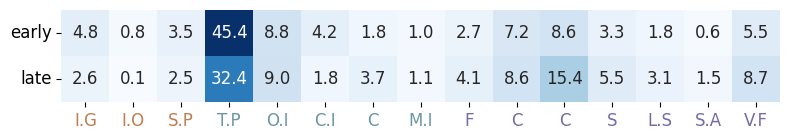

In [ ]:
ORDER = [
    'Idea Generation','Idea Organization','Section Planning','Text Production',
    'Object Insertion','Citation Integration','Cross-reference','Macro Insertion',
    'Fluency','Coherence','Clarity','Structural','Linguistic Style',
    'Scientific Accuracy','Visual Formatting'
]
def total_duration_prec(mode, n_perc=2):
  t_val = 5
  total_duration_store = dict()
  total_session_store = dict()
  for i in range(1, 6):
    project_df = all_sorted_df[all_sorted_df['project'] == i].sort_values(by="timestamp")
    records = project_df.to_dict(orient="records")
    if mode == "late":
      n = len(records)
      records = records[n*(n_perc-1)//n_perc:]
    elif mode == "early":
      n = len(records)
      records = records[:n//n_perc]
    total_duration, count, _ = time_spent_node_name(records, t_val, 10)
    # print("total sum", sum(total_duration.values()))
    total_duration_store[i] = total_duration
    total_session_store[i] = count

  df_total_duration = pd.DataFrame.from_dict(total_duration_store, orient="index")
  df_total_duration = df_total_duration.reset_index().rename(columns={"index": "project"})

  metric_cols = df_total_duration.columns.difference(['project'])

  # Sum across all projects
  total_row = df_total_duration[metric_cols].sum(axis=0)
  total_row = total_row / total_row.sum() * 100
  return total_row


color_map = {
    'Idea Generation': "#BF7E51",
    'Idea Organization': "#BF7E51",
    'Section Planning': "#BF7E51",
    'Text Production': "#6A96A7",
    'Object Insertion': "#6A96A7",
    'Citation Integration': "#6A96A7",
    'Cross-reference': "#6A96A7",
    'Macro Insertion': "#6A96A7",
    'Fluency': "#776AA7",
    'Coherence': "#776AA7",
    'Clarity': "#776AA7",
    'Structural': "#776AA7",
    'Linguistic Style': "#776AA7",
    'Scientific Accuracy': "#776AA7",
    'Visual Formatting': "#776AA7"
}



heatmap_early = total_duration_prec("early", 3)
heatmap_late = total_duration_prec("late", 3)
heatmap_all = total_duration_prec(None)
df_heatmaps = pd.DataFrame({
    # "all": heatmap_all,
    "early": heatmap_early,
    "late": heatmap_late
}).T.reset_index().rename(columns={"index": "mode"})

abbrev_map = {k: '.'.join([word[0] for word in k.split()]) for k in ORDER}

plt.figure(figsize=(8, 1.5))

ax = sns.heatmap(
    df_heatmaps.set_index("mode")[ORDER],
    cmap="Blues",
    annot=True,
    fmt=".1f",
    cbar=False,
    annot_kws={"size": 12},
)

# Set abbreviated x-ticks
ax.set_xticks(np.arange(len(ORDER)) + 0.5)
ax.set_xticklabels([abbrev_map[o] for o in ORDER], rotation=0, fontsize=12)

# Keep y-ticks normal
ax.set_yticks(np.arange(len(df_heatmaps["mode"])) + 0.5)
ax.set_yticklabels(df_heatmaps["mode"], rotation=0, fontsize=12)

# Color x-ticks using full label
for tick, full_label in zip(ax.get_xticklabels(), ORDER):
    if full_label in color_map:
        tick.set_color(color_map[full_label])

# Color y-ticks (optional — only if some modes have colors)
for tick in ax.get_yticklabels():
    label = tick.get_text()
    if label in color_map:
        tick.set_color(color_map[label])

plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig("duration_distribution_across_time.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

# Transition Probability by Timeline

/tmp/ipython-input-312638797.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(df, values="prob", index="row", columns="col", fill_value=0)
/tmp/ipython-input-312638797.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(df, values="prob", index="row", columns="col", fill_value=0)


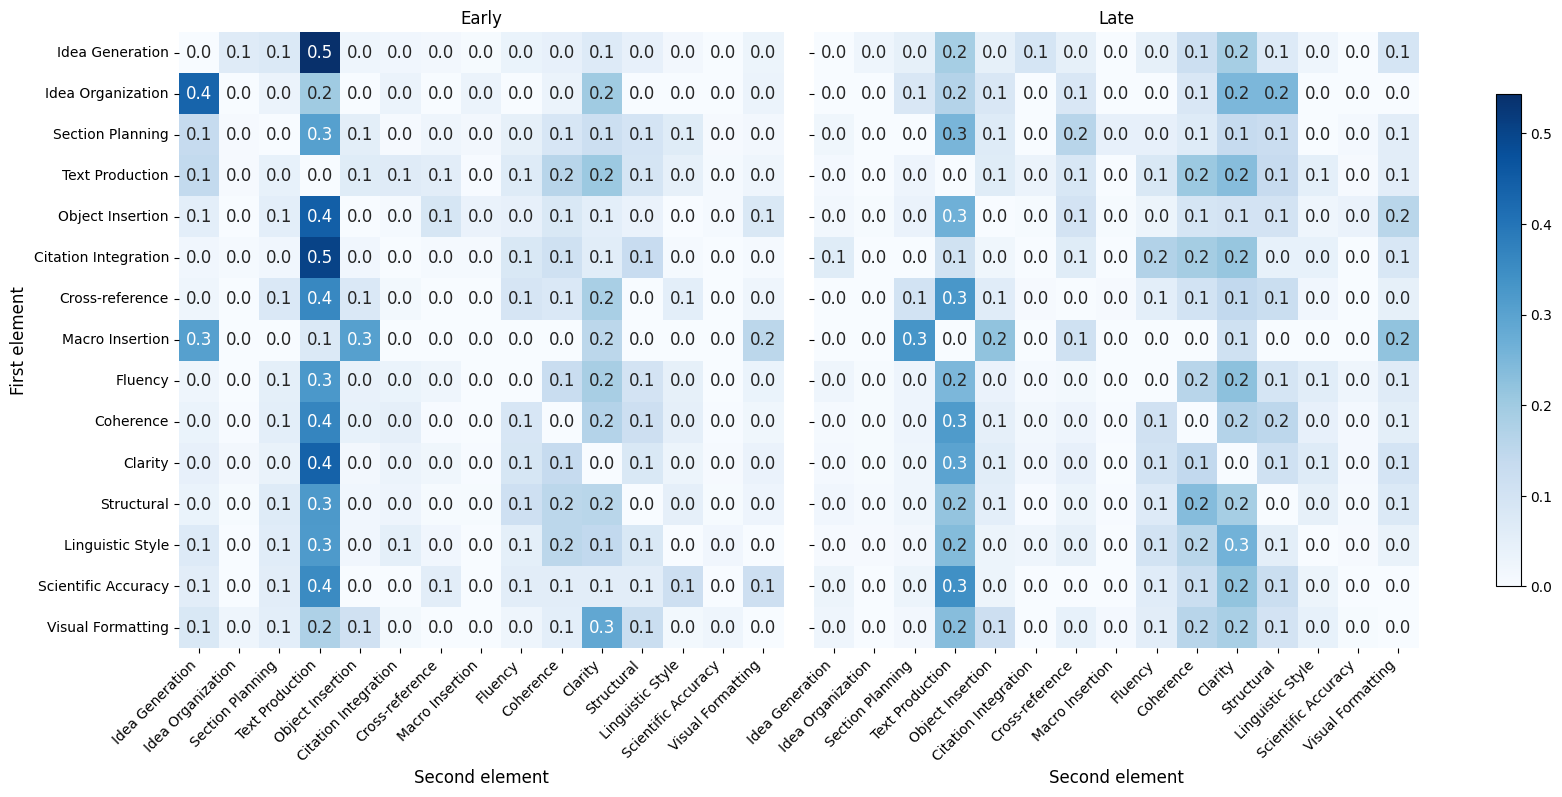

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ORDER = [
    'Idea Generation','Idea Organization','Section Planning','Text Production',
    'Object Insertion','Citation Integration','Cross-reference','Macro Insertion',
    'Fluency','Coherence','Clarity','Structural','Linguistic Style',
    'Scientific Accuracy','Visual Formatting'
]

def transition_matrix(all_sorted_df, projects=range(1,6), third=None):
    transitions = Counter()
    totals = Counter()

    for i in projects:
        project = all_sorted_df[all_sorted_df['project'] == i].sort_values(by="timestamp")
        labels = project['label'].tolist()
        if third == "late":
            labels = labels[len(labels)//3*2:]
        elif third == "early":
            labels = labels[:len(labels)//3]
        elif third == "mid":
            labels = labels[len(labels)//3:len(labels)//3*2]

        for j in range(len(labels) - 1):
            a, b = labels[j], labels[j+1]
            if a != b:
                transitions[(a, b)] += 1
                totals[a] += 1

    # Build prob triplets
    rows = []
    for (cur, nxt), cnt in transitions.items():
        prob = cnt / totals[cur] if totals[cur] else 0.0
        rows.append((cur, nxt, prob))

    df = pd.DataFrame(rows, columns=["row", "col", "prob"])
    # Ensure all labels appear (even if zero)
    df["row"] = pd.Categorical(df["row"], categories=ORDER, ordered=True)
    df["col"] = pd.Categorical(df["col"], categories=ORDER, ordered=True)
    mat = pd.pivot_table(df, values="prob", index="row", columns="col", fill_value=0)
    # Reindex to full square matrix
    mat = mat.reindex(index=ORDER, columns=ORDER, fill_value=0)
    return mat

# Compute early and late transition matrices
mat_late  = transition_matrix(all_sorted_df, projects=range(1,6), third="late")
mat_early = transition_matrix(all_sorted_df, projects=range(1,6), third="early")

# Shared color scale
vmax = max(mat_late.values.max(), mat_early.values.max())

# Plot side-by-side
fig, axes = plt.subplots(
    1, 2, figsize=(20, 8), sharex=True, sharey=True,
    gridspec_kw={"wspace": 0.05}
)
titles = ["Early", "Late"]
mats   = [mat_early, mat_late]

for ax, mat, title in zip(axes, mats, titles):
    sns.heatmap(mat, annot=True, fmt=".1f", cmap="Blues",
                vmin=0, vmax=vmax, ax=ax, cbar=False,
                annot_kws={"size": 12})
    ax.set_title(title, fontsize=12)
    ax.seat_xlabel("Second element", fontsize=12)
    if title == "Early":
        ax.set_ylabel("First element", fontsize=12)
    else:
        ax.set_ylabel("")
    # ax.set_xlabel("Second element")
    # ax.set_ylabel("First element" if title=="Early" else "")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Shared colorbar
cbar = fig.colorbar(axes[-1].collections[0], ax=axes, location="right", shrink=0.8)
# cbar.set_label("Probability")

# Save
plt.savefig("transition_prob_across_time.pdf", bbox_inches="tight", pad_inches=0)


/tmp/ipython-input-312638797.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(df, values="prob", index="row", columns="col", fill_value=0)


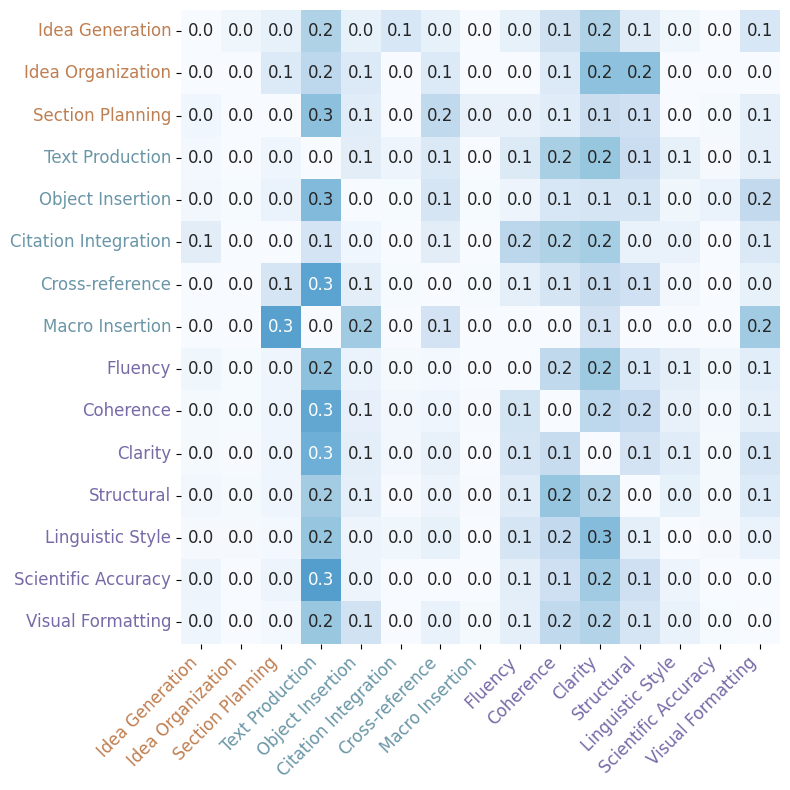

In [ ]:

color_map = {
    'Idea Generation': "#BF7E51",
    'Idea Organization': "#BF7E51",
    'Section Planning': "#BF7E51",
    'Text Production': "#6A96A7",
    'Object Insertion': "#6A96A7",
    'Citation Integration': "#6A96A7",
    'Cross-reference': "#6A96A7",
    'Macro Insertion': "#6A96A7",
    'Fluency': "#776AA7",
    'Coherence': "#776AA7",
    'Clarity': "#776AA7",
    'Structural': "#776AA7",
    'Linguistic Style': "#776AA7",
    'Scientific Accuracy': "#776AA7",
    'Visual Formatting': "#776AA7"
}

# Compute only the "all" matrix
mat_all = transition_matrix(all_sorted_df, projects=range(1, 6), third="late")

# Plot
plt.figure(figsize=(8, 8))
sns.heatmap(
    mat_all,
    annot=True, fmt=".1f", cmap="Blues",
    vmin=0, vmax=0.6,
    annot_kws={"size": 12},
    cbar_kws={'label': 'Probability'},
    cbar=False
)

# plt.xlabel("Next Intention")
# plt.ylabel("Current Intention")
plt.xlabel("")
# plt.ylabel("")
plt.ylabel(None)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)
# Color each x tick
for tick in plt.gca().get_xticklabels():
    label = tick.get_text()
    if label in color_map:
        tick.set_color(color_map[label])

# Color each y tick
for tick in plt.gca().get_yticklabels():
    label = tick.get_text()
    if label in color_map:
        tick.set_color(color_map[label])

plt.tight_layout()
plt.savefig("transition_prob_late_across_time.pdf", bbox_inches="tight", pad_inches=0)
plt.show()


/tmp/ipython-input-312638797.py:43: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(df, values="prob", index="row", columns="col", fill_value=0)


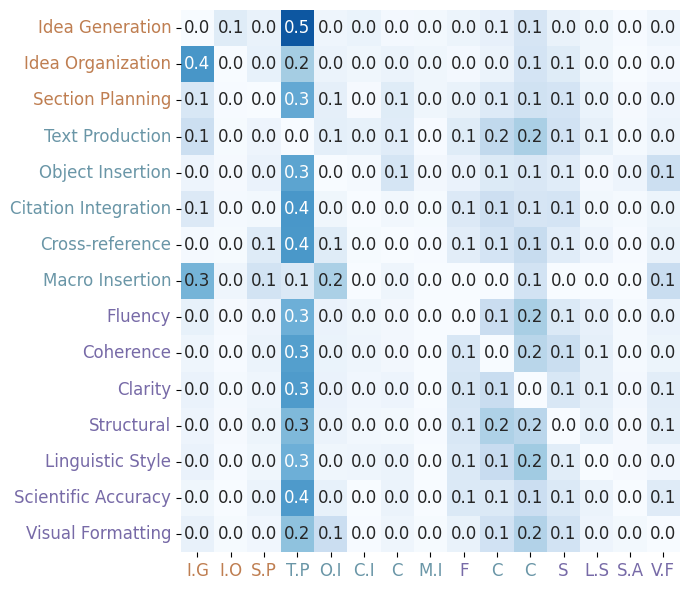

In [ ]:
# Create abbreviation map from color_map
abbrev_map = {k: '.'.join([word[0] for word in k.split()]) for k in color_map.keys()}
mat_all = transition_matrix(all_sorted_df, projects=range(1, 6), third="all")

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(
    mat_all,
    annot=True, fmt=".1f", cmap="Blues",
    vmin=0, vmax=0.6,
    annot_kws={"size": 12},
    cbar_kws={'label': 'Probability'},
    cbar=False
)

plt.xlabel("")
plt.ylabel(None)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()

# Abbreviate only x-tick labels
xticklabels = [abbrev_map.get(tick.get_text(), tick.get_text()) for tick in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels)

# Color x-tick labels based on original full label
for tick in ax.get_xticklabels():
    # Find the full label by matching abbreviation
    full_label = next((k for k, v in abbrev_map.items() if v == tick.get_text()), None)
    if full_label and full_label in color_map:
        tick.set_color(color_map[full_label])

# Keep y-tick full labels and colors
for tick in ax.get_yticklabels():
    label = tick.get_text()
    if label in color_map:
        tick.set_color(color_map[label])

plt.tight_layout()
plt.savefig("transition_prob_all.pdf", bbox_inches="tight", pad_inches=0)
plt.show()


In [ ]:
def transition_matrix_single_project(df, project_id):
    transitions = Counter()
    totals = Counter()

    project = df[df['project'] == project_id].sort_values(by="timestamp")
    labels = project['label'].tolist()

    for j in range(len(labels) - 1):
        a, b = labels[j], labels[j+1]
        if a != b:
            transitions[(a, b)] += 1
            totals[a] += 1

    rows = []
    for (cur, nxt), cnt in transitions.items():
        prob = cnt / totals[cur] if totals[cur] else 0.0
        rows.append((cur, nxt, prob))

    df_mat = pd.DataFrame(rows, columns=["row", "col", "prob"])
    df_mat["row"] = pd.Categorical(df_mat["row"], categories=ORDER, ordered=True)
    df_mat["col"] = pd.Categorical(df_mat["col"], categories=ORDER, ordered=True)

    mat = pd.pivot_table(
        df_mat, values="prob",
        index="row", columns="col",
        fill_value=0
    )

    return mat.reindex(index=ORDER, columns=ORDER, fill_value=0)


/tmp/ipython-input-2447179598.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(
/tmp/ipython-input-2447179598.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(
/tmp/ipython-input-2447179598.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  mat = pd.pivot_table(
/tmp/ipython-input-2447179598.py:23: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to s

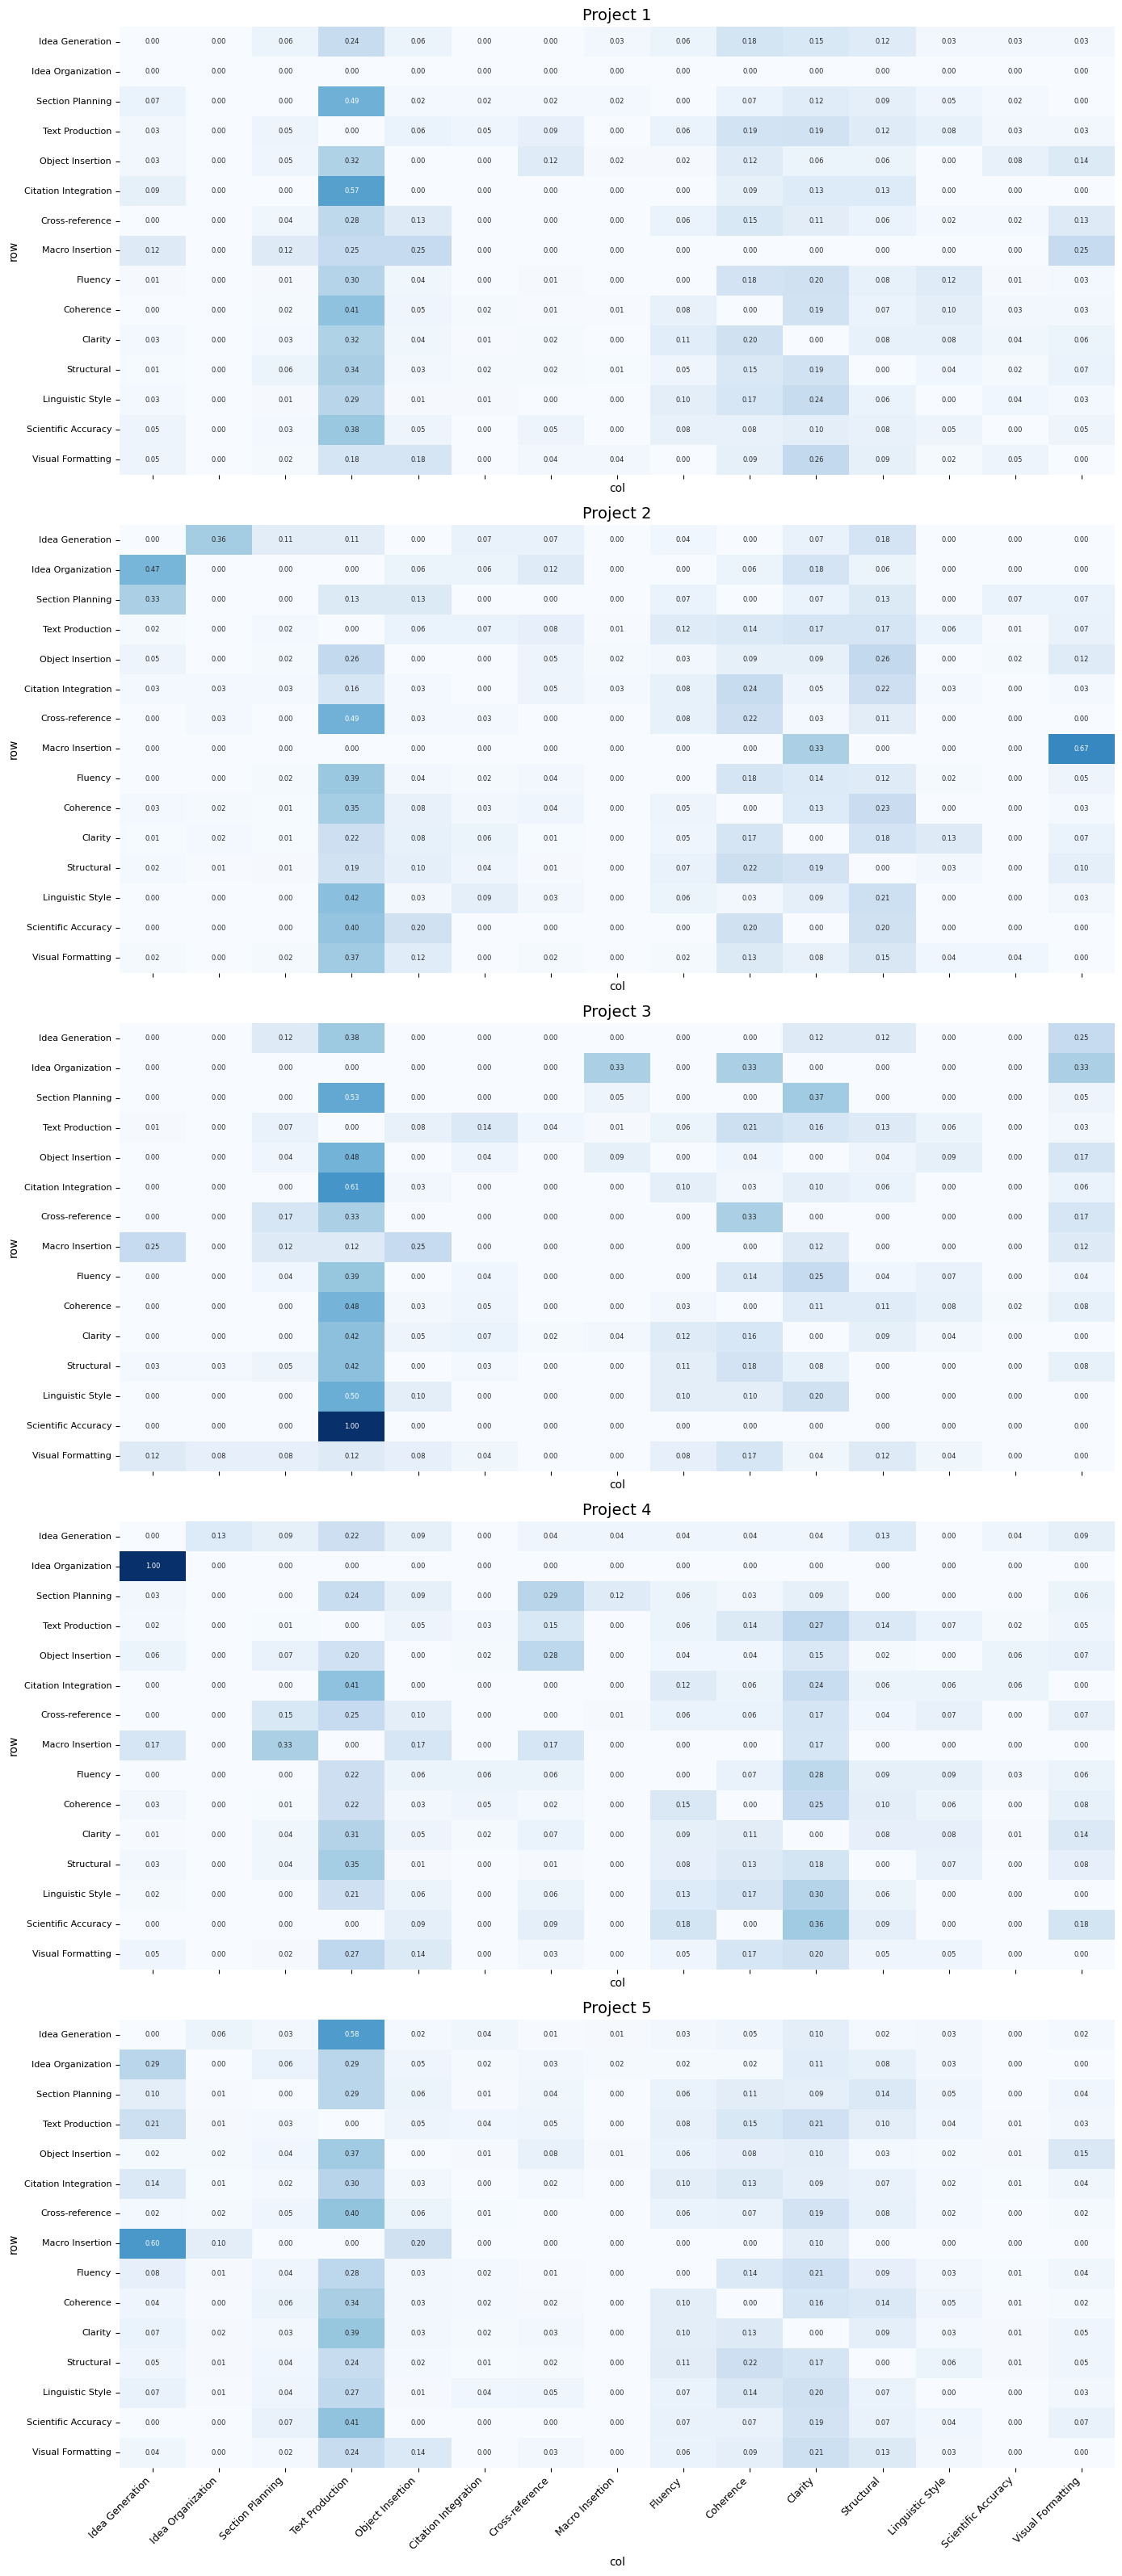

In [ ]:
from collections import Counter

matrices = {
    pid: transition_matrix_single_project(all_sorted_df, pid)
    for pid in range(1, 6)
}

fig, axes = plt.subplots(
    5, 1, figsize=(14, 32),
    sharex=True, sharey=True
)

vmax = max(mat.values.max() for mat in matrices.values())

for ax, pid in zip(axes, range(1,6)):
    sns.heatmap(
        matrices[pid],
        cmap="Blues",
        annot=True,          # 🔥 show values
        fmt=".2f",
        vmin=0,
        vmax=vmax,
        ax=ax,
        cbar=False,          # ❌ no colorbar
        annot_kws={"size": 6}  # smaller font for 15×15 values
    )

    ax.set_title(f"Project {pid}", fontsize=14)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig("transition_prob_each_project_annotated_no_legend.pdf",
            bbox_inches="tight", pad_inches=0)
plt.show()
